In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
# Load dataset
df = pd.read_csv(r"C:\Users\Tapan khandelwal\OneDrive\Desktop\Business\BusinessHealthEngine\data\sample_data.csv")

# Basic validation
required_columns = [
    "date", "revenue", "expenses", "profit",
    "projects_completed", "projects_delayed",
    "new_clients", "churned_clients",
    "late_payments", "customer_satisfaction"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All required columns present")

df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

print("Data shape:", df.shape)
df.head()

All required columns present
Data shape: (12, 11)


,revenue,expenses,profit,projects_completed,projects_delayed,new_clients,churned_clients,late_payments,outstanding_invoices,employee_satisfaction,customer_satisfaction
date,,,,,,,,,,,
2023-01-31,52000,36000,16000,8,2,4,1,3,23000,4.2,4.5
2023-02-28,54800,37800,17000,9,1,5,0,2,24500,4.3,4.6
2023-03-31,57500,39500,18000,10,2,6,1,4,26000,4.1,4.4
2023-04-30,60300,41000,19300,11,3,7,2,5,27500,4.0,4.3
2023-05-31,63400,43000,20400,12,2,8,1,3,29000,4.2,4.5


In [8]:
# Safe division using np.where to avoid ZeroDivision errors

df["profit_margin"] = np.where(
    df["revenue"] > 0,
    (df["profit"] / df["revenue"]) * 100,
    0
)

df["project_delay_rate"] = np.where(
    df["projects_completed"] > 0,
    (df["projects_delayed"] / df["projects_completed"]) * 100,
    0
)

df["client_churn_rate"] = np.where(
    (df["new_clients"] + df["churned_clients"]) > 0,
    (df["churned_clients"] /
     (df["new_clients"] + df["churned_clients"])) * 100,
    0
)

df["late_payment_rate"] = np.where(
    df["projects_completed"] > 0,
    (df["late_payments"] / df["projects_completed"]) * 100,
    0
)

print("Derived metrics safely added")
df.head()

Derived metrics safely added


,revenue,expenses,profit,projects_completed,projects_delayed,new_clients,churned_clients,late_payments,outstanding_invoices,employee_satisfaction,customer_satisfaction,profit_margin,project_delay_rate,client_churn_rate,late_payment_rate
date,,,,,,,,,,,,,,,
2023-01-31,52000,36000,16000,8,2,4,1,3,23000,4.2,4.5,30.769231,25.000000,20.000000,37.500000
2023-02-28,54800,37800,17000,9,1,5,0,2,24500,4.3,4.6,31.021898,11.111111,0.000000,22.222222
2023-03-31,57500,39500,18000,10,2,6,1,4,26000,4.1,4.4,31.304348,20.000000,14.285714,40.000000
2023-04-30,60300,41000,19300,11,3,7,2,5,27500,4.0,4.3,32.006633,27.272727,22.222222,45.454545
2023-05-31,63400,43000,20400,12,2,8,1,3,29000,4.2,4.5,32.176656,16.666667,11.111111,25.000000


In [9]:
df[[
    "revenue", "profit", "profit_margin",
    "project_delay_rate",
    "client_churn_rate",
    "late_payment_rate"
]].describe()

,revenue,profit,profit_margin,project_delay_rate,client_churn_rate,late_payment_rate
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,69100.000000,22241.666667,32.093998,25.874637,16.398544,37.548274
std,12090.868079,4268.373830,0.682726,7.703217,7.141167,9.258775
min,52000.000000,16000.000000,30.769231,11.111111,0.000000,22.222222
25%,59600.000000,18975.000000,31.831062,21.071429,13.492063,30.580357
50%,68150.000000,22150.000000,32.399180,26.136364,17.914439,38.750000
75%,77950.000000,25325.000000,32.558196,31.410256,21.626984,46.282051
max,89000.000000,29000.000000,32.783019,36.842105,25.000000,47.368421


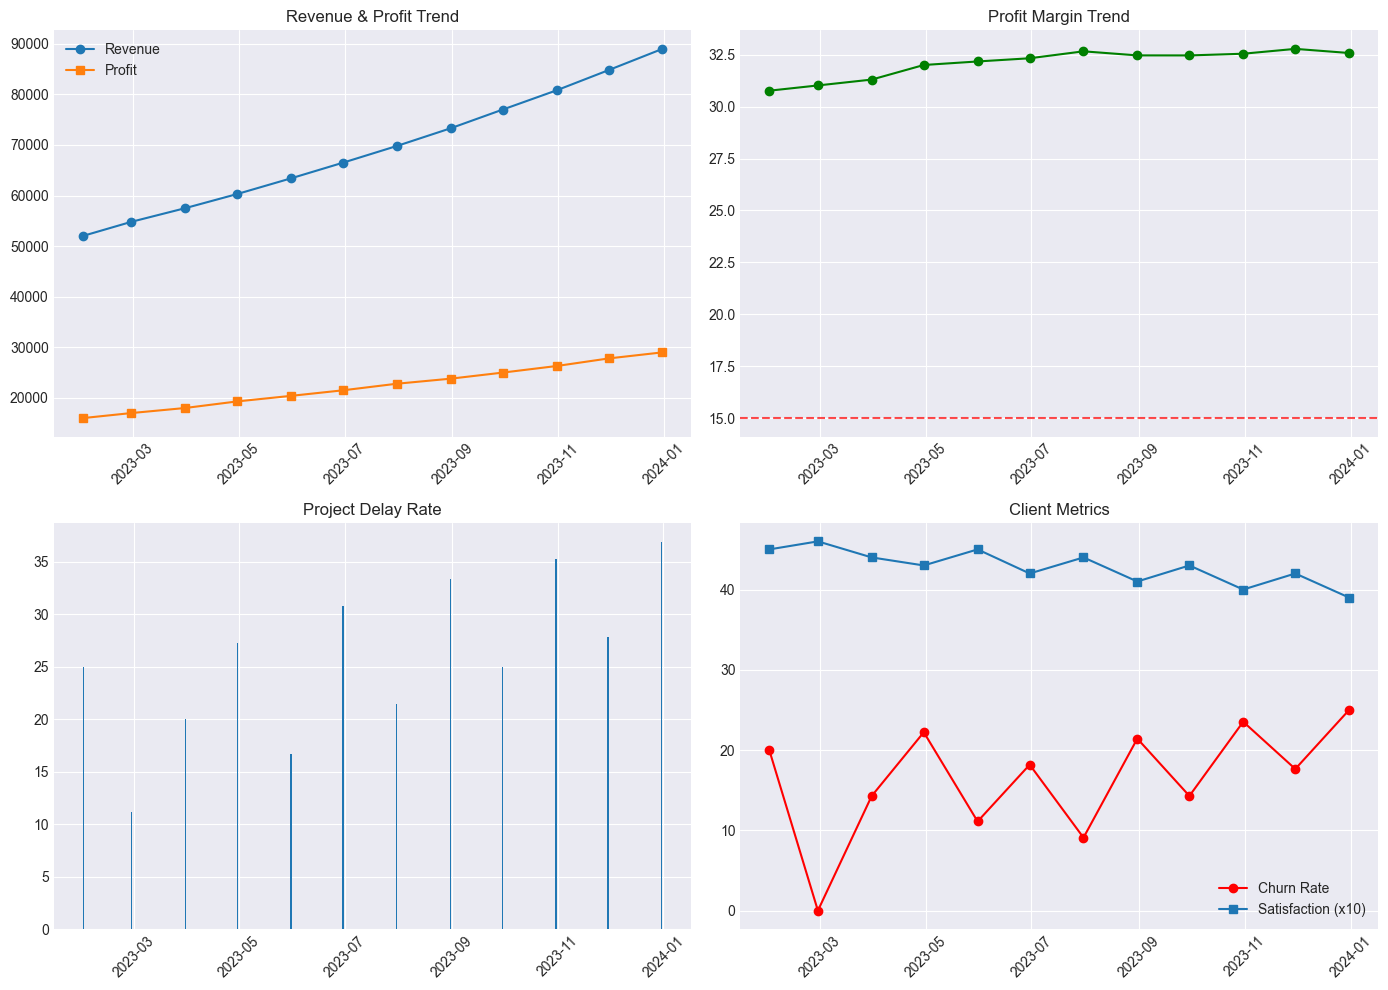

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue & Profit
axes[0,0].plot(df.index, df["revenue"], marker="o", label="Revenue")
axes[0,0].plot(df.index, df["profit"], marker="s", label="Profit")
axes[0,0].set_title("Revenue & Profit Trend")
axes[0,0].legend()
axes[0,0].tick_params(axis="x", rotation=45)

# Profit Margin
axes[0,1].plot(df.index, df["profit_margin"], marker="o", color="green")
axes[0,1].axhline(15, color="red", linestyle="--", alpha=0.7)
axes[0,1].set_title("Profit Margin Trend")
axes[0,1].tick_params(axis="x", rotation=45)

# Delay Rate
axes[1,0].bar(df.index, df["project_delay_rate"])
axes[1,0].set_title("Project Delay Rate")
axes[1,0].tick_params(axis="x", rotation=45)

# Client Metrics
axes[1,1].plot(df.index, df["client_churn_rate"], marker="o", color="red", label="Churn Rate")
axes[1,1].plot(df.index, df["customer_satisfaction"]*10, marker="s", label="Satisfaction (x10)")
axes[1,1].set_title("Client Metrics")
axes[1,1].legend()
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [11]:
def quick_health_score(row):
    score = 0

    # Financial (40)
    if row["profit_margin"] >= 15:
        score += 40
    elif row["profit_margin"] >= 10:
        score += 30
    elif row["profit_margin"] >= 5:
        score += 20
    else:
        score += 10

    # Operational (30)
    if row["project_delay_rate"] <= 10:
        score += 30
    elif row["project_delay_rate"] <= 20:
        score += 20
    else:
        score += 10

    # Client (30)
    if row["client_churn_rate"] <= 10:
        score += 30
    elif row["client_churn_rate"] <= 20:
        score += 20
    else:
        score += 10

    return score

df["health_score"] = df.apply(quick_health_score, axis=1)
df[["profit_margin", "project_delay_rate",
    "client_churn_rate", "health_score"]].tail()

,profit_margin,project_delay_rate,client_churn_rate,health_score
date,,,,
2023-08-31,32.469304,33.333333,21.428571,60
2023-09-30,32.467532,25.000000,14.285714,70
2023-10-31,32.549505,35.294118,23.529412,60
2023-11-30,32.783019,27.777778,17.647059,70
2023-12-31,32.584270,36.842105,25.000000,60


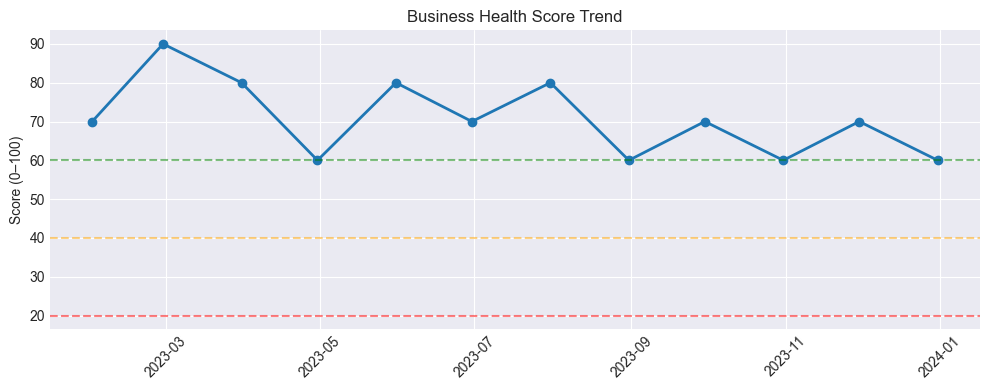

Current health score: 60
Average health score: 70.8


In [12]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df["health_score"], marker="o", linewidth=2)
plt.axhline(60, color="green", linestyle="--", alpha=0.5)
plt.axhline(40, color="orange", linestyle="--", alpha=0.5)
plt.axhline(20, color="red", linestyle="--", alpha=0.5)

plt.title("Business Health Score Trend")
plt.ylabel("Score (0–100)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Current health score:", df["health_score"].iloc[-1])
print("Average health score:", round(df["health_score"].mean(), 1))

In [13]:
print("="*60)
print("BUSINESS INSIGHT SUMMARY")
print("="*60)

print("\nFINANCIAL")
print("Avg Profit Margin:", round(df["profit_margin"].mean(),1), "%")
print("Total Revenue: $", format(df["revenue"].sum(), ","))
print("Total Profit: $", format(df["profit"].sum(), ","))

print("\nOPERATIONAL")
print("Avg Project Delay:", round(df["project_delay_rate"].mean(),1), "%")

print("\nCLIENT")
print("Avg Churn Rate:", round(df["client_churn_rate"].mean(),1), "%")
print("Avg Satisfaction:", round(df["customer_satisfaction"].mean(),2), "/5.0")

print("\nRISK FLAGS")
if df["profit_margin"].mean() < 15:
    print("- Profit margin below target")

if df["project_delay_rate"].mean() > 20:
    print("- High operational delays")

if df["client_churn_rate"].mean() > 15:
    print("- Client retention risk")

print("="*60)

BUSINESS INSIGHT SUMMARY

FINANCIAL
Avg Profit Margin: 32.1 %
Total Revenue: $ 829,200
Total Profit: $ 266,900

OPERATIONAL
Avg Project Delay: 25.9 %

CLIENT
Avg Churn Rate: 16.4 %
Avg Satisfaction: 4.28 /5.0

RISK FLAGS
- High operational delays
- Client retention risk
